# Model diagnostics & sanity checks
Diagnostic eval of the Conv1D-VAE + GRU world model variants A (lambda=0) / B (1) / C (5), seed 0, on the
held-out TEST split. No retraining. Helper functions carry inline `assert` tests. Sections: A confusion
matrices, B lightcurves, C UMAP, D control baselines, E latent health, F astrophysical sanity.

In [ ]:
import random

In [ ]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors
import umap
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
from swm.models import WorldModel

EXP = "exp00_window1024_seq4"          # this notebook is the exp00 (1024x4) baseline diagnostic
exp_dir = root / "experiments" / EXP   # packed/ + models/ live here; subset/ + labels/ stay shared at repo root
WINDOW = 1024
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
VARIANTS = ["A", "B", "C"]
TASKS = ["transit", "eb", "pulsating"]
print("device", device)

In [ ]:
subset = pd.read_parquet(root / "processed/subset/subset_tics.parquet")
labels = pd.read_csv(root / "labels/variability_labels_star.csv")
test_idx = pd.read_parquet(exp_dir / "packed/test_index.parquet")
train_idx = pd.read_parquet(exp_dir / "packed/train_index.parquet")
test_total = int(test_idx["n_win"].sum())
train_total = int(train_idx["n_win"].sum())
test_mm = np.memmap(exp_dir / "packed/test_windows.dat", dtype=np.float32, mode="r", shape=(test_total, WINDOW))
train_mm = np.memmap(exp_dir / "packed/train_windows.dat", dtype=np.float32, mode="r", shape=(train_total, WINDOW))

star_mu = {}
for v in VARIANTS:
    star_mu[v] = pd.read_parquet(exp_dir / f"models/{v}_seed0/extracted/star_mu.parquet")

mu_cols = []
for c in star_mu["A"].columns:
    if c.startswith("mu"):
        mu_cols.append(c)

data = {}
for v in VARIANTS:
    data[v] = star_mu[v].merge(subset[["tic_id"] + TASKS], on="tic_id", how="inner")

shapes = {}
for v in VARIANTS:
    shapes[v] = data[v].shape
print(shapes)

## Helpers (with inline tests)

In [3]:
def concat_segment_lightcurve(windows_mm, row_start, n_win):
    """Concatenate a segment's packed windows in row order into one 1D lightcurve."""
    block = np.array(windows_mm[row_start : row_start + n_win], dtype=np.float32) # (n_win, 1024) copy -> writable
    return block.reshape(-1)

_r = test_idx.iloc[0]
_lc = concat_segment_lightcurve(test_mm, int(_r["row_start"]), int(_r["n_win"]))
assert _lc.shape[0] == int(_r["n_win"]) * WINDOW and np.isfinite(_lc).all()
print("ok concat ->", _lc.shape[0])

ok concat -> 4096


In [15]:
def probe_task(frame, mu_cols, task):
    """Fit StandardScaler + balanced LogisticRegression on per-star mu; return (metrics, test preds, clf)."""
    tr, te = frame[frame["split"] == "train"], frame[frame["split"] == "test"]
    sc = StandardScaler()
    xtr = sc.fit_transform(tr[mu_cols].to_numpy()); xte = sc.transform(te[mu_cols].to_numpy())
    clf = LogisticRegression(class_weight="balanced", max_iter=2000).fit(xtr, tr[task].to_numpy())
    score = clf.predict_proba(xte)[:, 1]; pred = (score >= 0.5).astype(int); y = te[task].to_numpy()
    metrics = {"pr_auc": float(average_precision_score(y, score)), "roc_auc": float(roc_auc_score(y, score)),
               "f1": float(f1_score(y, pred)), "macro_f1": float(f1_score(y, pred, average="macro")),
               "n_test_pos": int(y.sum()), "n_test": int(len(y))}
    preds = pd.DataFrame({"tic_id": te["tic_id"].to_numpy(), "score": score, "pred": pred, "label": y})
    return metrics, preds, clf

_m, _p, _ = probe_task(data["A"], mu_cols, "pulsating")
assert abs(_m["pr_auc"] - 0.7202) < 0.01 and len(_p) == _m["n_test"] # reproduces results_table.csv
print("ok probe A/pulsating pr_auc", round(_m["pr_auc"], 4))

ok probe A/pulsating pr_auc 0.7202


In [16]:
def confusion_counts(y_true, y_pred):
    """2x2 [[TN,FP],[FN,TP]]."""
    return confusion_matrix(y_true, y_pred, labels=[0, 1])

_cm = confusion_counts(_p["label"], _p["pred"])
assert _cm.sum() == _m["n_test"] and _cm[1, 1] + _cm[1, 0] == _m["n_test_pos"]
print("ok confusion", _cm.ravel().tolist())

ok confusion [1736, 69, 31, 185]


In [17]:
def summary_stat_features(lc):
    """Hand-crafted summary features of one lightcurve (non-deep probe baseline)."""
    std = float(np.std(lc))
    if std > 0:
        skew = float(stats.skew(lc))
        kurt = float(stats.kurtosis(lc))
    else:
        skew = 0.0
        kurt = 0.0
    return {"std": std, "mad": float(np.median(np.abs(lc - np.median(lc)))),
            "skew": skew, "kurt": kurt,
            "range": float(np.ptp(lc)), "n_peaks": int(len(find_peaks(lc)[0]))}

_f = summary_stat_features(_lc); _fc = summary_stat_features(np.ones(100, dtype=np.float32))
assert all(np.isfinite(v) for v in _f.values()) and _fc["std"] == 0.0 and _fc["skew"] == 0.0
print("ok summary_stats", {k: round(v, 2) for k, v in _f.items()})

ok summary_stats {'std': 1.15, 'mad': 0.68, 'skew': 0.24, 'kurt': -0.22, 'range': 6.13, 'n_peaks': 1346}


In [18]:
def knn_precision_at_k(mu, labels, k):
    """Mean over positives of the fraction of k nearest neighbors (excluding self) that are positive."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(mu)
    _, idx = nn.kneighbors(mu)
    nb = idx[:, 1:]
    pos = np.where(labels == 1)[0]
    fractions = []
    for r in pos:
        fractions.append(labels[nb[r]].mean())
    return float(np.mean(fractions))

_rng = np.random.default_rng(0)
_blob = np.vstack([_rng.normal(0, 0.1, (30, 4)), _rng.normal(10, 0.1, (30, 4))]); _lab = np.array([1]*30 + [0]*30)
assert knn_precision_at_k(_blob, _lab, 5) == 1.0
print("ok knn separable=1.0")

ok knn separable=1.0


In [19]:
def pointbiserial_per_dim(mu, label):
    """Point-biserial correlation of each latent dim with a binary label."""
    corrs = []
    for d in range(mu.shape[1]):
        corrs.append(stats.pointbiserialr(label, mu[:, d]).correlation)
    return np.array(corrs)

def period_bucket(period, edges, names):
    """Assign a period (days) to a labeled bucket given ascending edges."""
    for i in range(len(edges)):
        if period < edges[i]:
            return names[i]
    return names[-1]

_pb = pointbiserial_per_dim(data["A"][mu_cols].to_numpy(), data["A"]["pulsating"].to_numpy())
assert _pb.shape[0] == 128
assert period_bucket(0.5, [1, 5, 10], ["a", "b", "c", "d"]) == "a" and period_bucket(20, [1, 5, 10], ["a","b","c","d"]) == "d"
print("ok pointbiserial max|corr|", round(np.abs(_pb).max(), 3), "| period_bucket")

ok pointbiserial max|corr| 0.184 | period_bucket


In [80]:
# Section B helper: deterministic single-curve picker (sorted by tic_id)
test_first = test_idx.sort_values(["tic_id", "sector", "seg_idx"]).drop_duplicates("tic_id").set_index("tic_id")

def star_lc(tic):
    """Concatenate a star's first test-split segment into one 1D light curve."""
    r = test_first.loc[tic]
    return concat_segment_lightcurve(test_mm, int(r["row_start"]), int(r["n_win"]))

def task_tics(task, label_value, variant="B"):
    """Test-split TICs for one task/label, sorted by tic_id so index order is deterministic."""
    d = data[variant]; d = d[d["split"] == "test"]
    return np.sort(d[d[task] == label_value]["tic_id"].to_numpy())

def plot_one_lc(ax, task, label_value, idx, variant="B"):
    """Plot a single light curve for task/label at position idx (wraps modulo); returns the tic."""
    tics = task_tics(task, label_value, variant)
    assert len(tics) > 0, f"no test stars for {task}={label_value}"
    tic = int(tics[idx % len(tics)])
    ax.plot(star_lc(tic), lw=0.6)
    ax.set_title(f"{task}={label_value}  TIC{tic}  [idx {idx % len(tics)}]")
    return tic

def plot_pos_neg_lc(task, pos_idx, neg_idx, variant="B"):
    """Two-panel single-curve view: positive (label=1) vs negative (label=0) for one task."""
    fig, axes = plt.subplots(1, 2, figsize=(17, 4))
    plot_one_lc(axes[0], task, 1, pos_idx, variant)
    plot_one_lc(axes[1], task, 0, neg_idx, variant)
    plt.tight_layout(); plt.show()

assert len(task_tics("pulsating", 1)) and len(task_tics("pulsating", 0))
print("ok helper:", len(task_tics("pulsating", 1)), "pos /", len(task_tics("pulsating", 0)), "neg (pulsating)")


ok helper: 216 pos / 1805 neg (pulsating)


In [ ]:
# Section B helper: TP/FP/TN/FN confusion-quadrant light curves (input + recon overlay)
def load_model(variant="B"):
    """Load a trained variant's world model from its best checkpoint (eval mode)."""
    ck = torch.load(exp_dir / f"models/{variant}_seed0/best.pt", map_location=device, weights_only=False); c = ck["cfg"]
    mdl = WorldModel(in_ch=c["model"]["in_ch"], enc_channels=c["model"]["enc_channels"], kernel_size=c["model"]["kernel_size"],
                     z_dim=c["model"]["z_dim"], window=c["data"]["window"], gru_hidden=c["model"]["gru_hidden"],
                     gru_layers=c["model"]["gru_layers"]).to(device)
    mdl.load_state_dict(ck["model"]); mdl.eval(); return mdl

_model_cache = {}
def get_model(variant="B"):
    """Load + cache a variant's model so repeated plotting calls don't reload from disk."""
    if variant not in _model_cache:
        _model_cache[variant] = load_model(variant)
    return _model_cache[variant]

model_B = get_model("B")  # kept available for the downstream latent-health cell

def segment_input_recon(model, tic):
    """Return (input_lc, recon_lc) for a star's first test segment, decoded by model."""
    r = test_first.loc[tic]; blk = np.array(test_mm[int(r["row_start"]):int(r["row_start"]) + int(r["n_win"])], dtype=np.float32)
    x = torch.from_numpy(blk).unsqueeze(-1).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(x); rec = model.decoder(mu)
    return blk.reshape(-1), rec[:, :, 0].cpu().numpy().reshape(-1)

def cm_group_tics(task, label_value, pred_value, variant="B"):
    """Test TICs in one confusion quadrant (label, pred), sorted by tic_id for deterministic indexing."""
    p = preds[(variant, task)]
    sub = p[(p["label"] == label_value) & (p["pred"] == pred_value)]
    return np.sort(sub["tic_id"].to_numpy())

def plot_one_quadrant(ax, task, name, label_value, pred_value, idx, variant="B"):
    """Plot one confusion-quadrant star (input + recon) at position idx (wraps modulo); returns tic or None."""
    tics = cm_group_tics(task, label_value, pred_value, variant)
    if len(tics) == 0:
        ax.set_title(f"{task} {name}: none"); ax.set_xticks([]); ax.set_yticks([]); return None
    tic = int(tics[idx % len(tics)])
    lc, rec = segment_input_recon(get_model(variant), tic)
    ax.plot(lc, lw=0.5, alpha = 1, label="input"); ax.plot(rec, lw=0.5, alpha = 1, label="recon")
    ax.set_title(f"{task} {name}  TIC{tic}  [idx {idx % len(tics)}]")
    return tic

def plot_confusion_lcs(task, tp_idx=0, fp_idx=0, tn_idx=0, fn_idx=0, variant="B"):
    """2x2 (TP,FP)/(TN,FN) view; each quadrant independently indexed. Large subplots for fine detail."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    quads = [("TP", 1, 1, tp_idx), ("FP", 0, 1, fp_idx), ("TN", 0, 0, tn_idx), ("FN", 1, 0, fn_idx)]
    for ax, (name, lv, pv, idx) in zip(axes.ravel(), quads):
        plot_one_quadrant(ax, task, name, lv, pv, idx, variant)
    axes[0, 0].legend(); fig.suptitle(f"{task}: TP / FP (top row), TN / FN (bottom row)"); plt.tight_layout(); plt.show()

print("ok confusion helper: model_B loaded, plot_confusion_lcs ready")

## A. Probe metrics + confusion matrices

In [22]:
rows, preds, clfs = [], {}, {}
for v in VARIANTS:
    for t in TASKS:
        m, p, clf = probe_task(data[v], mu_cols, t)
        m.update({"variant": v, "task": t}); rows.append(m); preds[(v, t)] = p; clfs[(v, t)] = clf
metrics_df = pd.DataFrame(rows)[["variant", "task", "pr_auc", "roc_auc", "f1", "macro_f1", "n_test_pos", "n_test"]]
metrics_df

,variant,task,pr_auc,roc_auc,f1,macro_f1,n_test_pos,n_test
0,A,transit,0.095895,0.643984,0.160878,0.424740,122,2021
1,A,eb,0.742063,0.907814,0.571429,0.755189,196,2021
2,A,pulsating,0.720228,0.961047,0.787234,0.879619,216,2021
3,B,transit,0.105719,0.673771,0.168913,0.426553,122,2021
4,B,eb,0.747627,0.907646,0.580271,0.759355,196,2021
5,B,pulsating,0.743896,0.975510,0.820084,0.897977,216,2021
6,C,transit,0.129074,0.698323,0.165304,0.426413,122,2021
7,C,eb,0.735400,0.901317,0.565891,0.751182,196,2021
8,C,pulsating,0.726249,0.974392,0.792373,0.882461,216,2021


Plain f1: F1 of positive class only; harmonic mean of precision+recall
- computed only on class-1 predictions. Ignores how well model do on class 0.

macro_f1: compute F1 separately for class 0 AND class 1, then avg



`n_test_pos`: how many of those are positive (label=1)

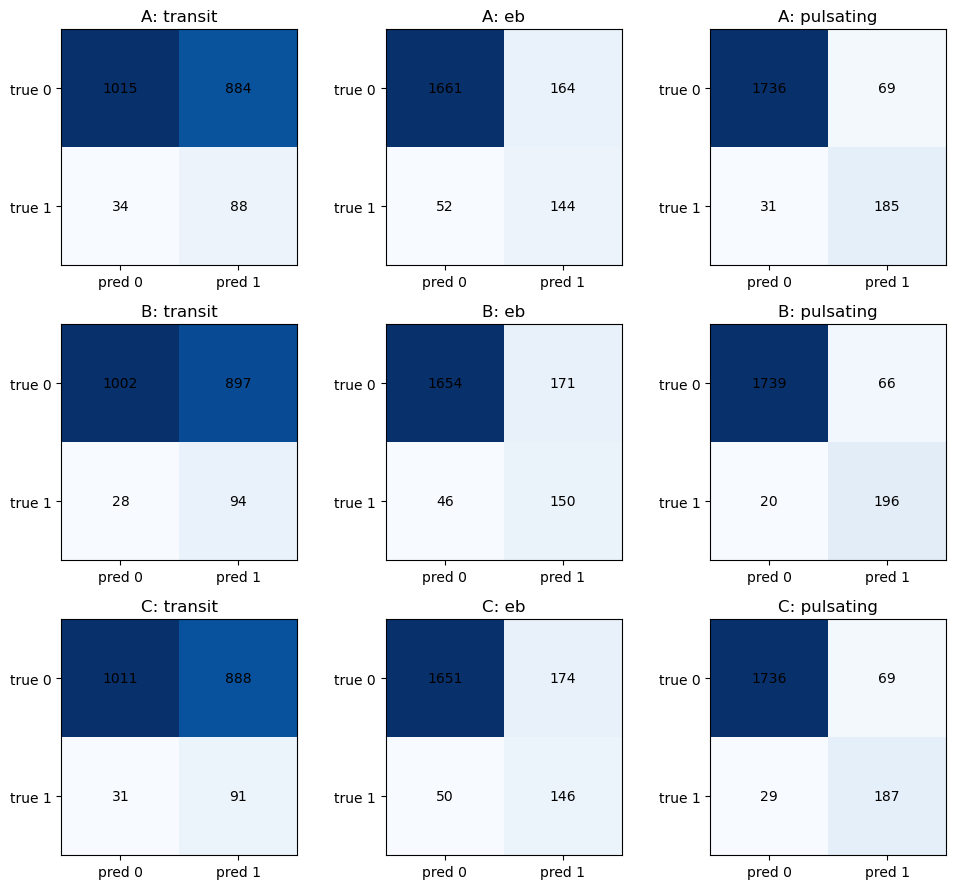

In [71]:
fig, axes = plt.subplots(len(VARIANTS), len(TASKS), figsize=(10, 9))
for i, v in enumerate(VARIANTS):
    for j, t in enumerate(TASKS):
        cm = confusion_counts(preds[(v, t)]["label"].to_numpy(), preds[(v, t)]["pred"].to_numpy())
        ax = axes[i, j]; ax.imshow(cm, cmap="Blues")
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha="center", va="center")
        ax.set_title(f"{v}: {t}"); ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(["pred 0", "pred 1"]); ax.set_yticklabels(["true 0", "true 1"])
plt.tight_layout(); plt.show()

## B. Lightcurve inspection
Lightcurves are the packed (MAD-normalized, NaN-free) windows the model saw, concatenated within a segment.

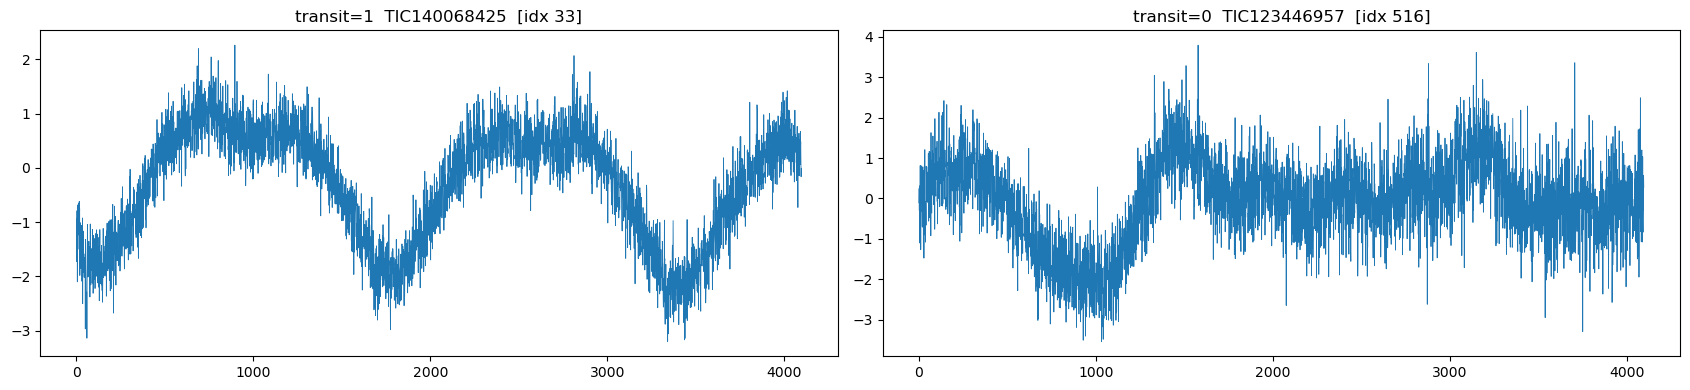

In [119]:
# Transit: switch curves by changing pos_idx / neg_idx
rng_b1 = np.random.default_rng()
pos_idx, neg_idx = int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000))
#pos_idx, neg_idx = 2, 2
plot_pos_neg_lc("transit", pos_idx, neg_idx)


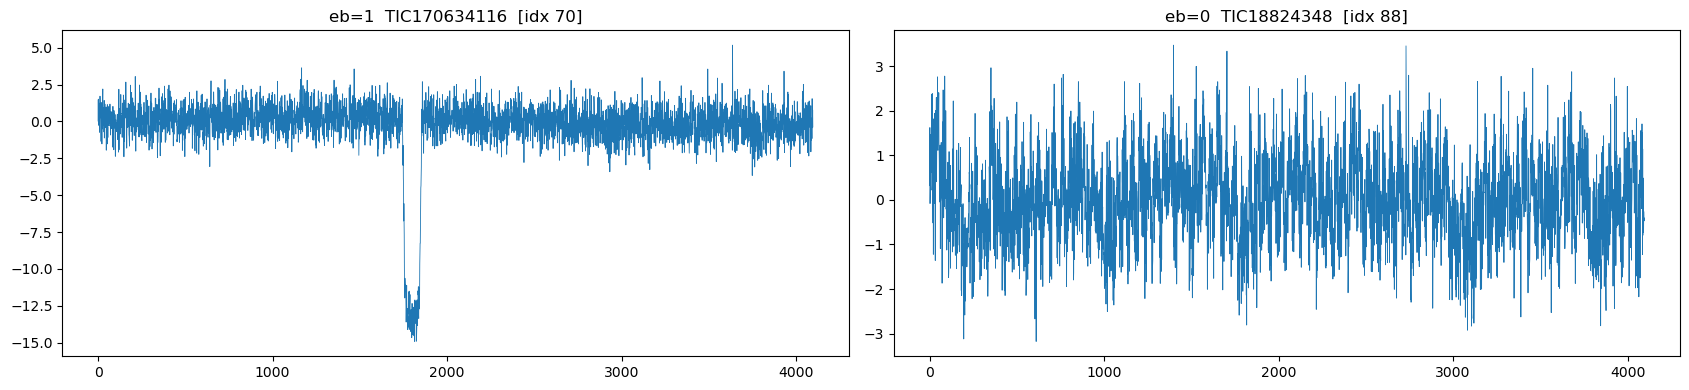

In [141]:
# Eb: switch curves by changing pos_idx / neg_idx
rng_b1 = np.random.default_rng()
pos_idx, neg_idx = int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000))
#pos_idx, neg_idx = 6, 2
plot_pos_neg_lc("eb", pos_idx, neg_idx)


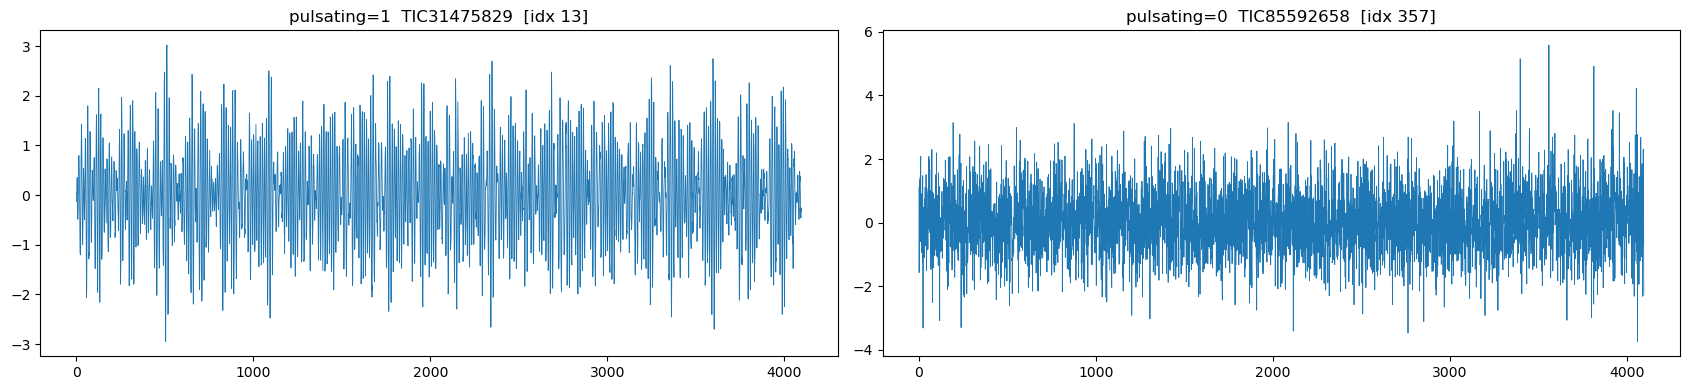

In [161]:
# Pulsating: switch curves by changing pos_idx / neg_idx
rng_b1 = np.random.default_rng()
pos_idx, neg_idx = int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000))
#pos_idx, neg_idx = 0, 0
plot_pos_neg_lc("pulsating", pos_idx, neg_idx)


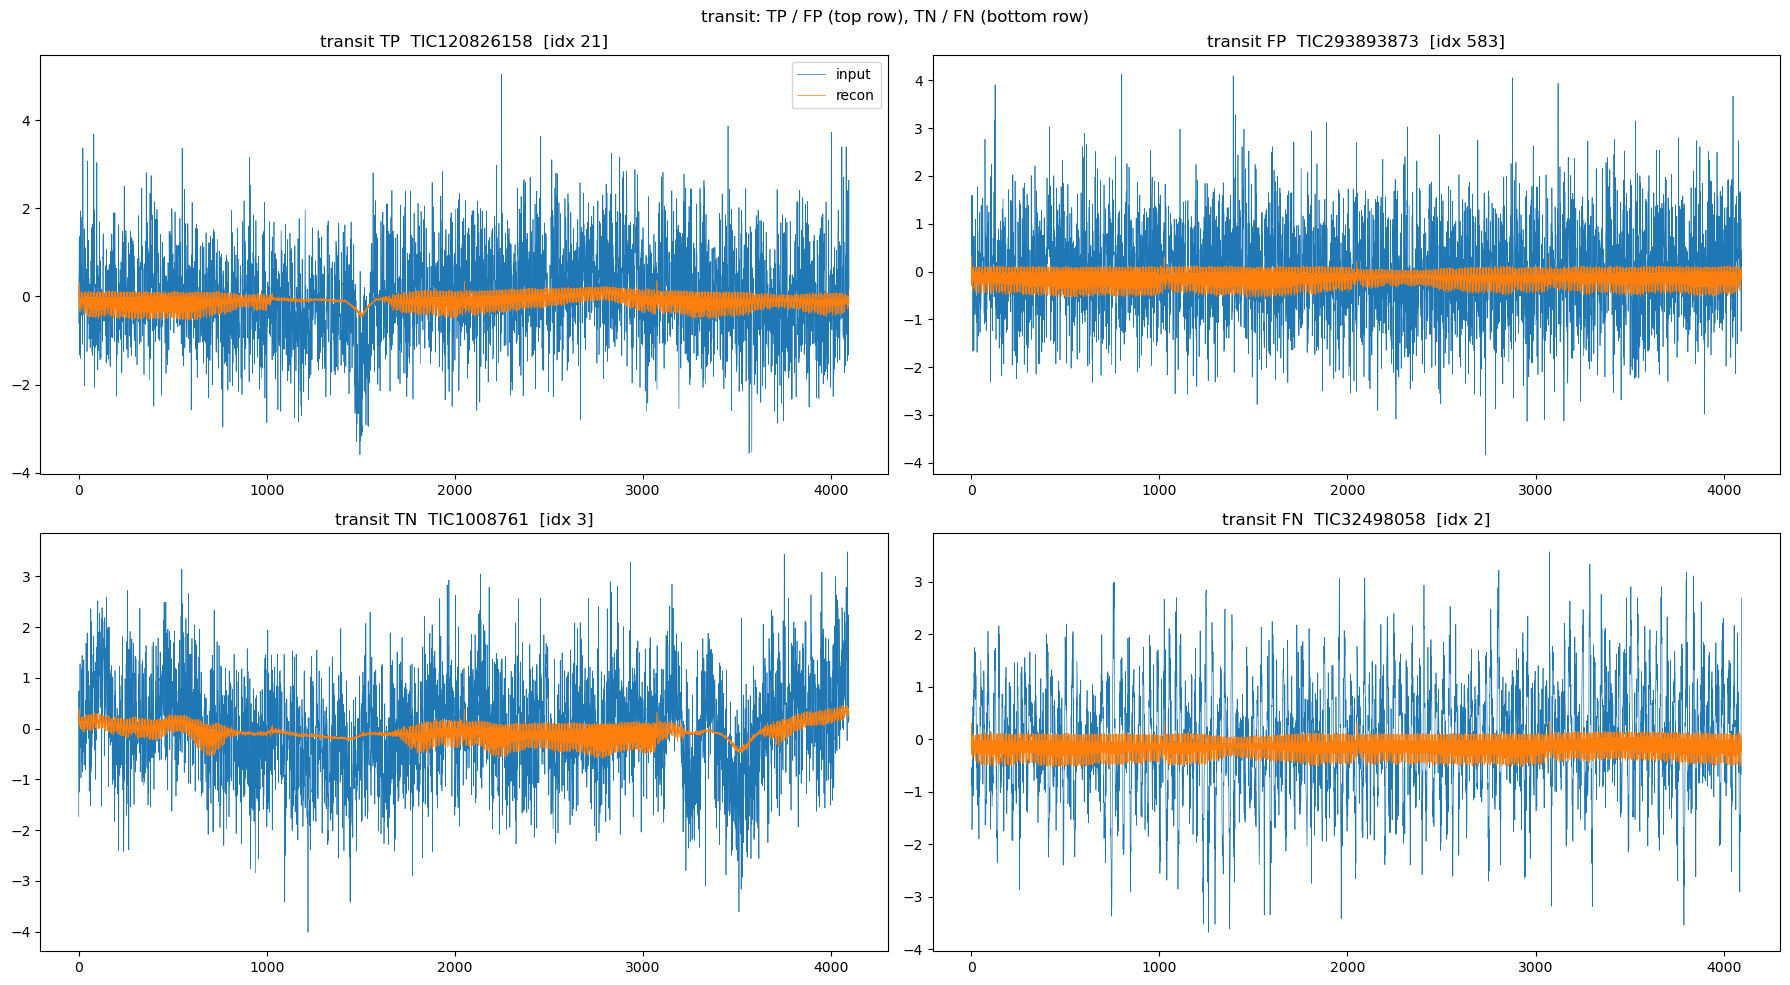

In [178]:
# Transit TP/FP/TN/FN — change the four indices to switch the curve shown in each quadrant
# tp_idx, fp_idx, tn_idx, fn_idx = 1, 1, 1, 1
rng_b1 = np.random.default_rng()
tp_idx, fp_idx, tn_idx, fn_idx = int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000))

plot_confusion_lcs("transit", tp_idx, fp_idx, tn_idx, fn_idx)


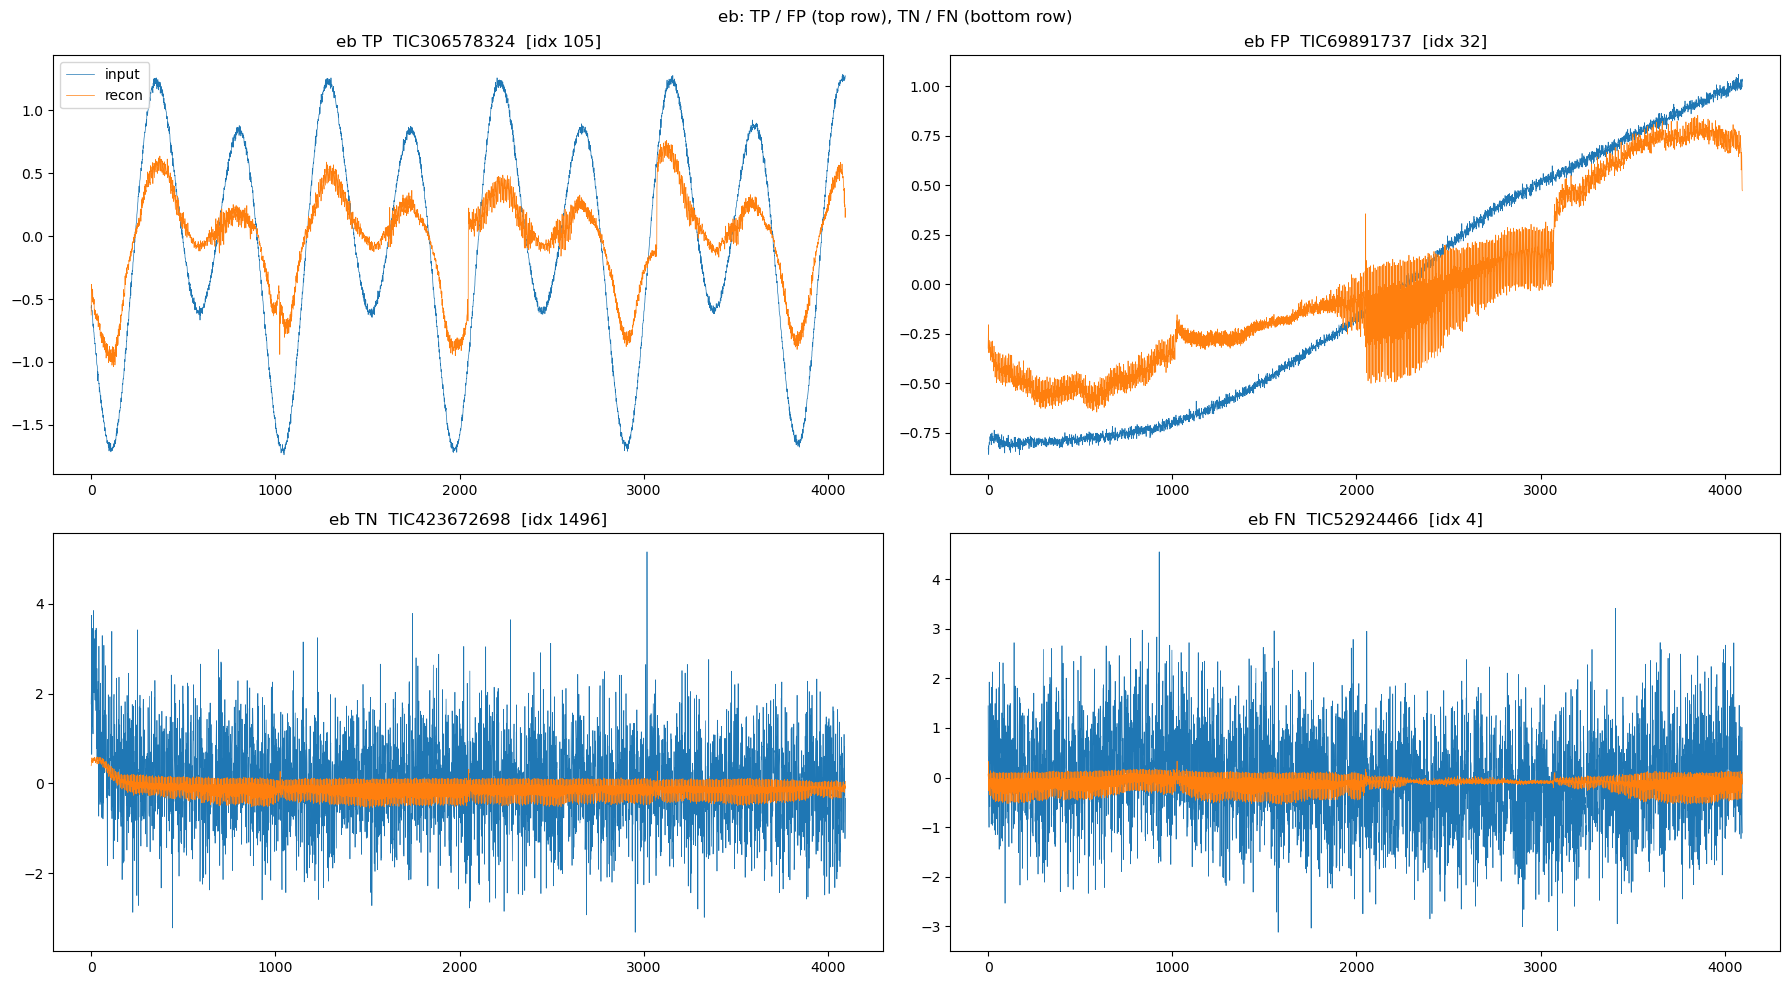

In [188]:
# EB TP/FP/TN/FN — change the four indices to switch the curve shown in each quadrant
#tp_idx, fp_idx, tn_idx, fn_idx = 1, 1, 1, 1
rng_b1 = np.random.default_rng()
tp_idx, fp_idx, tn_idx, fn_idx = int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000))
plot_confusion_lcs("eb", tp_idx, fp_idx, tn_idx, fn_idx)


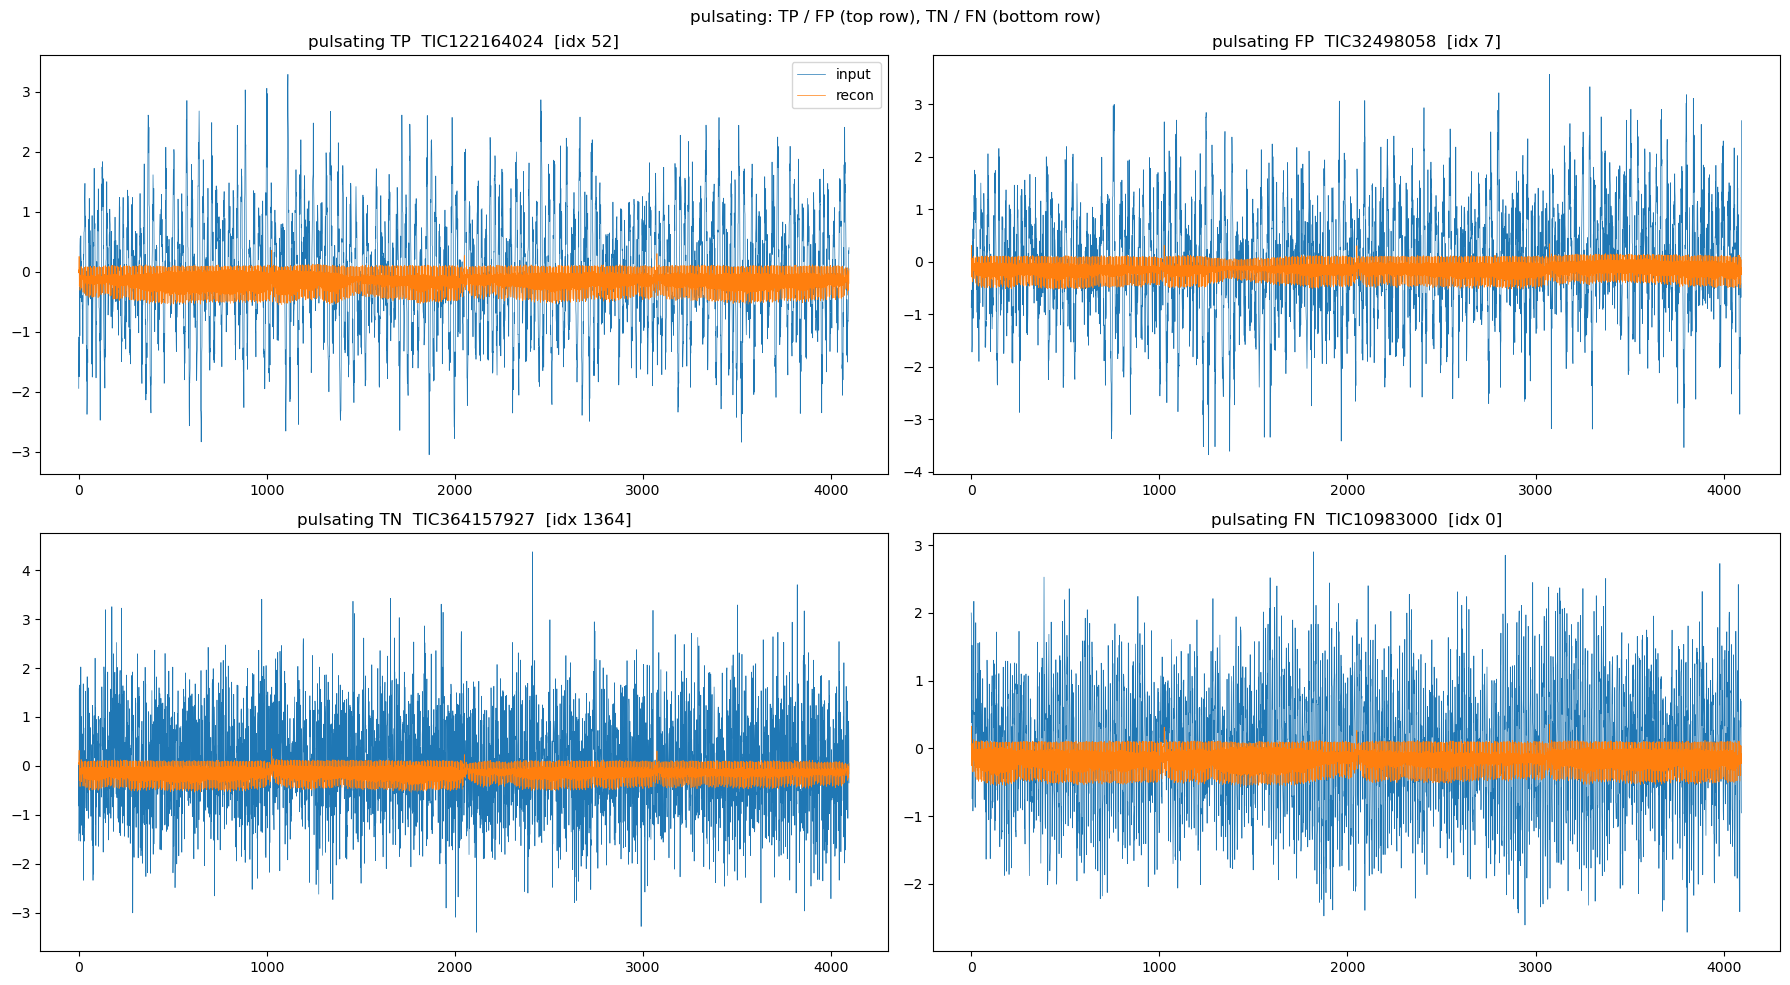

In [200]:
# Pulsating TP/FP/TN/FN — change the four indices to switch the curve shown in each quadrant
#tp_idx, fp_idx, tn_idx, fn_idx = 0, 0, 0, 0
rng_b1 = np.random.default_rng()
tp_idx, fp_idx, tn_idx, fn_idx = int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000)), int(rng_b1.integers(0, 10000))
plot_confusion_lcs("pulsating", tp_idx, fp_idx, tn_idx, fn_idx)


## C. UMAP of the latent (test split)
Colored by class (rarest-first: transit > eb > pulsating > quiet).

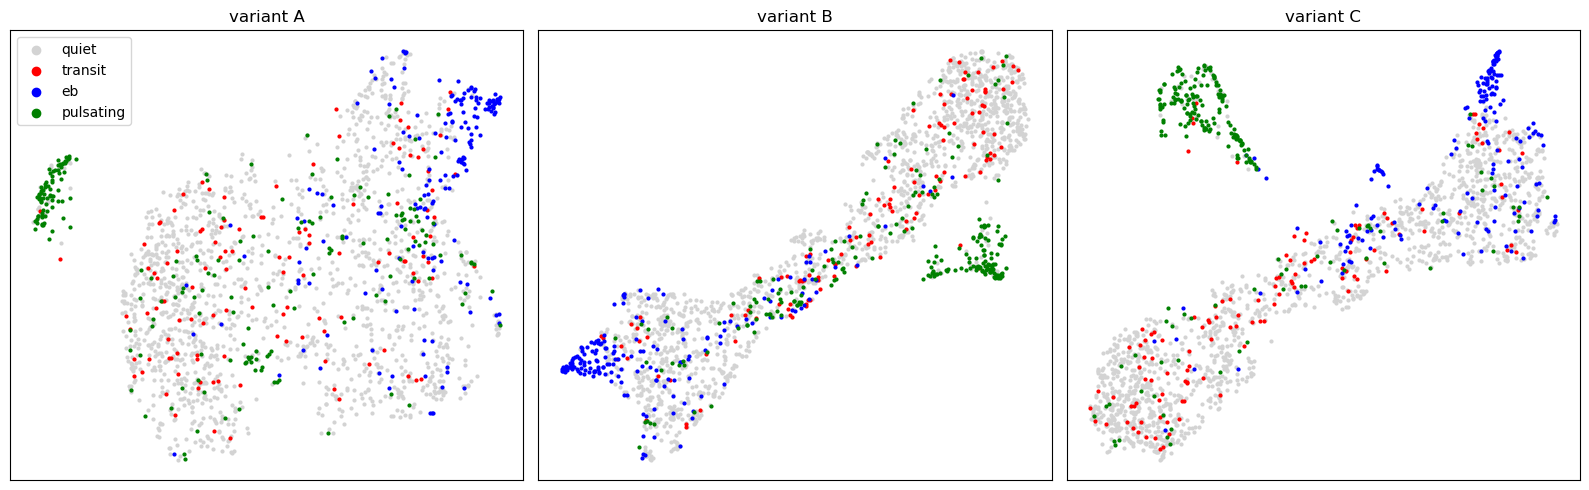

In [73]:
def class_of(row):
    if row["transit"] == 1: return "transit"
    if row["eb"] == 1: return "eb"
    if row["pulsating"] == 1: return "pulsating"
    return "quiet"

test_data = {v: data[v][data[v]["split"] == "test"].reset_index(drop=True) for v in VARIANTS}
emb = {v: umap.UMAP(n_neighbors=15, random_state=42).fit_transform(test_data[v][mu_cols].to_numpy()) for v in VARIANTS}
palette = {"quiet": "lightgray", "transit": "red", "eb": "blue", "pulsating": "green"}
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(16, 5))
for i, v in enumerate(VARIANTS):
    cls = test_data[v].apply(class_of, axis=1).to_numpy()
    for name, color in palette.items():
        mask = cls == name
        axes[i].scatter(emb[v][mask, 0], emb[v][mask, 1], s=4, c=color, label=name)
    axes[i].set_title(f"variant {v}"); axes[i].set_xticks([]); axes[i].set_yticks([])
axes[0].legend(markerscale=3, loc="best"); plt.tight_layout(); plt.show()

## D. Control baselines
Is the SSL latent doing anything? Compare trained probe vs untrained-encoder, summary-stat features, and label-shuffle (must collapse to base rate). Baselines use each star's first segment for tractability.

In [ ]:
train_first = train_idx.sort_values(["tic_id", "sector", "seg_idx"]).drop_duplicates("tic_id").set_index("tic_id")

def rep_windows(tic, split):
    idx, mm = (test_first, test_mm) if split == "test" else (train_first, train_mm)
    r = idx.loc[tic]; return np.array(mm[int(r["row_start"]):int(r["row_start"]) + int(r["n_win"])], dtype=np.float32)

split_of = star_mu["A"].set_index("tic_id")["split"]
stars = star_mu["A"][["tic_id"]].merge(split_of.reset_index(), on="tic_id")
stars = stars[stars["split"].isin(["train", "test"])].reset_index(drop=True)

@torch.no_grad()
def encoder_repfeatures(model):
    out = []
    for tic in stars["tic_id"]:
        w = rep_windows(int(tic), split_of.loc[int(tic)])
        x = torch.from_numpy(w).unsqueeze(-1).to(device)
        out.append(model.encoder(x)[0].mean(0).cpu().numpy())
    df = pd.DataFrame(out, columns=mu_cols); df.insert(0, "tic_id", stars["tic_id"].to_numpy()); return df

def stat_repfeatures():
    rows = []
    for tic in stars["tic_id"]:
        lc = rep_windows(int(tic), split_of.loc[int(tic)]).reshape(-1); rows.append(summary_stat_features(lc))
    df = pd.DataFrame(rows); df.insert(0, "tic_id", stars["tic_id"].to_numpy()); return df

torch.manual_seed(0)
ck = torch.load(exp_dir / "models/A_seed0/best.pt", map_location=device, weights_only=False); c = ck["cfg"]
untrained = WorldModel(in_ch=c["model"]["in_ch"], enc_channels=c["model"]["enc_channels"], kernel_size=c["model"]["kernel_size"],
                       z_dim=c["model"]["z_dim"], window=c["data"]["window"], gru_hidden=c["model"]["gru_hidden"],
                       gru_layers=c["model"]["gru_layers"]).to(device).eval()
untr = encoder_repfeatures(untrained).merge(subset[["tic_id"] + TASKS], on="tic_id").merge(split_of.reset_index(), on="tic_id")
stat = stat_repfeatures().merge(subset[["tic_id"] + TASKS], on="tic_id").merge(split_of.reset_index(), on="tic_id")
stat_cols = ["std", "mad", "skew", "kurt", "range", "n_peaks"]
print("baseline feature tables", untr.shape, stat.shape)

**trained_B** — real result. Take trained encoder B → per-star latent μ → logistic regression probe → PR-AUC on test.
This is "does SSL work" number. Pulled from results_table.csv.

**untrained_enc** — same pipeline but encoder weights = random, never trained (untr). Measures skill from architecture
alone, zero learning. probe_task(untr, mu_cols, t).

**summary_stat** — throw away encoder. Feed probe hand-made numbers per star (mean, std,mad, skew, kurt, range, n_peaks of flux). Measures "could dumb stats do it". probe_task(stat, stat_cols, t).

**label_shuffle** — trained B features, but labels randomly permuted (np.random.permutation). Breaks feature↔label link. Should collapse to chance. Sanity floor = probe not cheating.

**base_rate** — fraction of test stars that ARE positive. data["B"][test][t].mean(). = PR-AUC of random guesser.
Absolute floor.

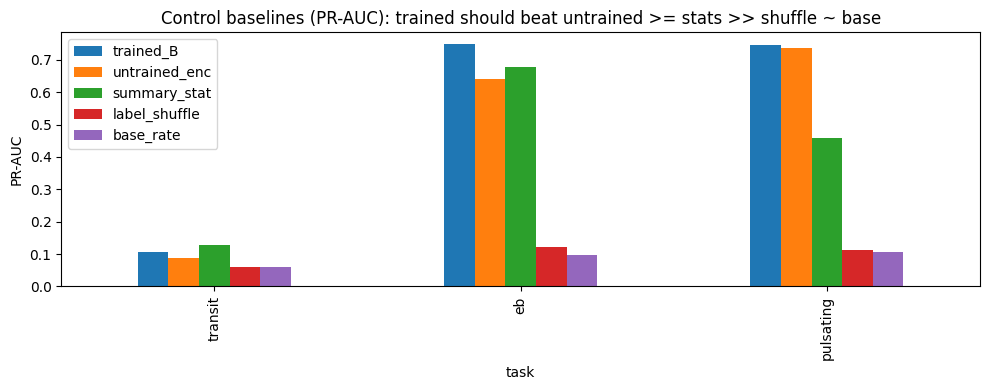

,task,base_rate,trained_B,untrained_enc,summary_stat,label_shuffle
0,transit,0.060366,0.105794,0.089287,0.129489,0.061156
1,eb,0.096982,0.747380,0.639983,0.677572,0.120747
2,pulsating,0.106878,0.744278,0.735628,0.459019,0.111739


In [15]:
base_rows = []
for t in TASKS:
    base = data["B"][data["B"]["split"] == "test"][t].mean()
    trained = metrics_df[(metrics_df["variant"] == "B") & (metrics_df["task"] == t)]["pr_auc"].iloc[0]
    untr_m = probe_task(untr, mu_cols, t)[0]["pr_auc"]
    stat_m = probe_task(stat, stat_cols, t)[0]["pr_auc"]
    sh = data["B"].copy(); sh[t] = np.random.default_rng(0).permutation(sh[t].to_numpy())
    shuf_m = probe_task(sh, mu_cols, t)[0]["pr_auc"]
    base_rows.append({"task": t, "base_rate": base, "trained_B": trained, "untrained_enc": untr_m,
                      "summary_stat": stat_m, "label_shuffle": shuf_m})
base_df = pd.DataFrame(base_rows)
ax = base_df.set_index("task")[["trained_B", "untrained_enc", "summary_stat", "label_shuffle", "base_rate"]].plot.bar(figsize=(10, 4))
ax.set_ylabel("PR-AUC"); plt.title("Control baselines (PR-AUC): trained should beat untrained >= stats >> shuffle ~ base"); plt.tight_layout(); plt.show()
base_df

## E. Latent health (N1)
True KL settled well below the free-bits floor in training; here we see how few latent dims actually carry information.

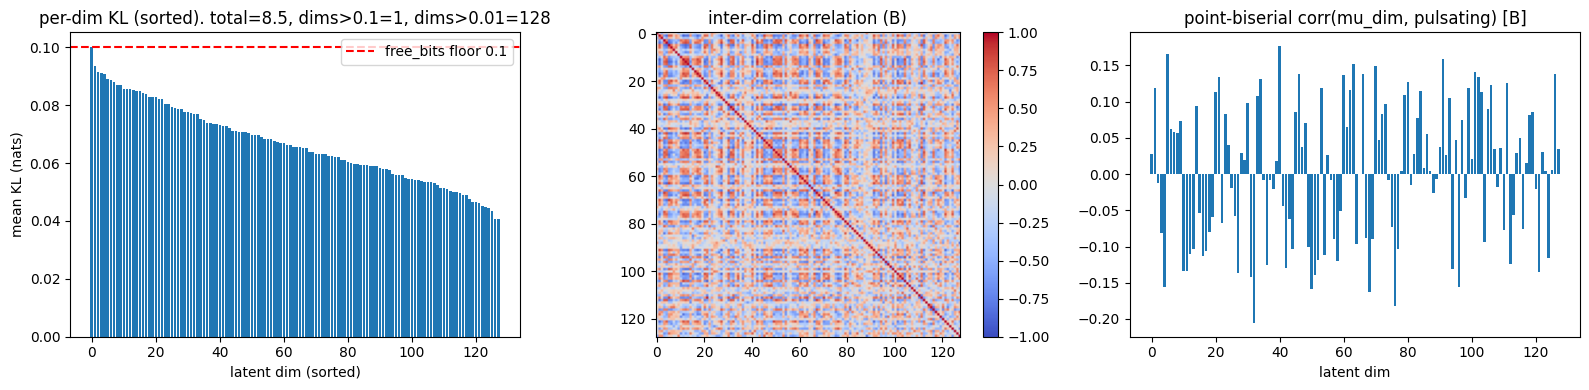

In [16]:
@torch.no_grad()
def encode_test_mu_logvar(model):
    mus, lvs = [], []
    for i in range(0, test_total, 4096):
        blk = np.array(test_mm[i:i + 4096], dtype=np.float32); x = torch.from_numpy(blk).unsqueeze(-1).to(device)
        mu, lv = model.encoder(x); mus.append(mu.cpu().numpy()); lvs.append(lv.cpu().numpy())
    return np.concatenate(mus), np.concatenate(lvs)

mu_t, lv_t = encode_test_mu_logvar(model_B)
kl_dim = 0.5 * (mu_t ** 2 + np.exp(lv_t) - lv_t - 1.0)
kl_dim_mean = kl_dim.mean(axis=0)
floor = 0.1
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(range(128), np.sort(kl_dim_mean)[::-1]); ax[0].axhline(floor, color="red", ls="--", label=f"free_bits floor {floor}")
ax[0].set_title(f"per-dim KL (sorted). total={kl_dim_mean.sum():.1f}, dims>0.1={int((kl_dim_mean>0.1).sum())}, dims>0.01={int((kl_dim_mean>0.01).sum())}")
ax[0].set_xlabel("latent dim (sorted)"); ax[0].set_ylabel("mean KL (nats)"); ax[0].legend()
corr = np.corrcoef(test_data["B"][mu_cols].to_numpy().T)
im = ax[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1); ax[1].set_title("inter-dim correlation (B)"); fig.colorbar(im, ax=ax[1])
pb = pointbiserial_per_dim(test_data["B"][mu_cols].to_numpy(), test_data["B"]["pulsating"].to_numpy())
ax[2].bar(range(128), pb); ax[2].set_title("point-biserial corr(mu_dim, pulsating) [B]"); ax[2].set_xlabel("latent dim")
plt.tight_layout(); plt.show()

**1st subplot**: 
  Each bar calc:
  - Encode every test window → mu, logvar, 128 dims each.
  - Per-dim KL = 0.5*(mu² + exp(logvar) − logvar − 1) = KL divergence between that dim's
  posterior N(mu, σ²) and prior N(0,1). One value per dim per window.
  - Average over all test windows → kl_dim_mean, 128 numbers.
  - Sort descending → one bar per dim. Red dashed = free_bits floor 0.1.

  **What show**: how much info each latent dim carries (nats). Tall = dim used, near-zero = dim dead
  (posterior collapse).

  **Subplot 3** — point-biserial corr(mu_dim, pulsating)
  What show: does any individual latent dim act as pulsating detector?

  **Combined story**: subplot 1 = latent barely regularized + redundant (KL too low, floor too high).
  subplot 3 = even the class that works (pulsating) only weakly imprinted per-dim. Both point
  same way → bottleneck not doing real work.

## F. Astrophysical sanity

In [17]:
def stratified_pr(variant, task, period_col, edges, names):
    p = preds[(variant, task)].merge(labels[["tic_id", period_col]], on="tic_id", how="left")
    pos = p[p["label"] == 1].copy(); pos["bucket"] = pos[period_col].apply(lambda x: period_bucket(x, edges, names) if pd.notna(x) else "no_period")
    out = []
    for b in names:
        bucket_pos = pos[pos["bucket"] == b]
        neg = p[p["label"] == 0]
        if len(bucket_pos) < 3:
            out.append({"bucket": b, "n_pos": len(bucket_pos), "pr_auc": np.nan}); continue
        sub = pd.concat([bucket_pos, neg])
        out.append({"bucket": b, "n_pos": len(bucket_pos), "pr_auc": float(average_precision_score(sub["label"], sub["score"]))})
    return pd.DataFrame(out)

eb_strat = stratified_pr("B", "eb", "eb_period", [1, 5, 10], ["<1d", "1-5d", "5-10d", ">=10d"])
puls_strat = stratified_pr("B", "pulsating", "pulsating_period", [0.2, 2, 5], ["<0.2d", "0.2-2d", "2-5d", ">=5d"])
print("EB period-stratified PR-AUC (B):"); display(eb_strat)
print("Pulsating period-stratified PR-AUC (B):"); display(puls_strat)

EB period-stratified PR-AUC (B):


,bucket,n_pos,pr_auc
0,<1d,47,0.655444
1,1-5d,94,0.779803
2,5-10d,28,0.489175
3,>=10d,27,0.077503


Pulsating period-stratified PR-AUC (B):


,bucket,n_pos,pr_auc
0,<0.2d,200,0.741826
1,0.2-2d,3,0.020042
2,2-5d,6,0.061679
3,>=5d,7,0.056398


In [18]:
# transit-EB confound: are transit false positives eclipsing binaries?
te = data["B"][data["B"]["split"] == "test"].merge(preds[("B", "transit")][["tic_id", "pred"]], on="tic_id")
fp = te[(te["transit"] == 0) & (te["pred"] == 1)]
print(f"transit FPs: {len(fp)}, of which eb=1: {int(fp['eb'].sum())} ({100*fp['eb'].mean():.0f}%)")
print(f"test eb base rate: {100*te['eb'].mean():.1f}%  ->  EBs {'over' if fp['eb'].mean()>te['eb'].mean() else 'not over'}-represented among transit FPs")
print(pd.crosstab(te["transit"], te["eb"]))

transit FPs: 895, of which eb=1: 61 (7%)
test eb base rate: 9.7%  ->  EBs not over-represented among transit FPs
eb          0    1
transit           
0        1715  184
1         110   12


tested hypothesis: **transit failures = EB lookalikes** 

- Data says no — EBs appear less often in FPs than at random. 

- Transit FPs are some other junk, not EB contamination.

In [19]:
# kNN retrieval precision@k in the latent (probe-independent separability)
knn_rows = []
for v in VARIANTS:
    for t in TASKS:
        td = test_data[v]
        knn_rows.append({"variant": v, "task": t, "base_rate": round(td[t].mean(), 3),
                         "knn_prec@10": round(knn_precision_at_k(td[mu_cols].to_numpy(), td[t].to_numpy(), 10), 3)})
pd.DataFrame(knn_rows)

,variant,task,base_rate,knn_prec@10
0,A,transit,0.060,0.143
1,A,eb,0.097,0.401
2,A,pulsating,0.107,0.395
3,B,transit,0.060,0.156
4,B,eb,0.097,0.419
5,B,pulsating,0.107,0.425
6,C,transit,0.060,0.172
7,C,eb,0.097,0.413
8,C,pulsating,0.107,0.574


**knn_prec@10** = "if I stand on a positive star and look at its 10 closest neighbors, what fraction are same-class?"

base_rate = fraction of test stars in that class (td[t].mean()). = what random retrieval scores

  Compare prec@10 vs base_rate → lift = separability:
  - transit: 0.143–0.172 vs base 0.060 → ~2.5× base but absolute low. Weakly clustered.
  - eb: ~0.40–0.42 vs base 0.097 → ~4× base. Clearly clustered.
  - pulsating: 0.40 (A) → 0.43 (B) → 0.57 (C) vs base 0.107 → strong, rises with dynamics weight λ.